In [1]:
# %% [code]
# 1) Imports & settings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)


In [2]:
# %% [code]
# 2) Load dataset
DATA_PATH = r"D:\virtual environment\used_cars.csv"   # adjust if needed
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (4009, 12)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [3]:
# %% [code]
# Quick info & missing values
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB
None

Missing values per column:
brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596

In [4]:
# %% [code]
# 3) Basic cleaning of textual numeric columns: price and milage
def clean_price(x):
    if pd.isna(x): 
        return np.nan
    s = str(x).replace("$", "").replace(",", "").strip()
    try:
        return float(s)
    except:
        return np.nan

def clean_milage(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower().replace("mi", "").replace("miles", "").replace(",", "").strip()
    # keep numbers only (some entries may have 'k' or similar; handle basic cases)
    try:
        return float(s)
    except:
        # try extract digits
        import re
        m = re.search(r"([\d\.]+)", s)
        if m:
            return float(m.group(1))
        return np.nan

df['price_clean'] = df['price'].apply(clean_price)
df['milage_clean'] = df['milage'].apply(clean_milage)

# Drop rows with missing target price
df = df[~df['price_clean'].isnull()].copy()

print("After cleaning price/milage:", df.shape)
print(df[['price', 'price_clean', 'milage', 'milage_clean']].head())


After cleaning price/milage: (4009, 14)
     price  price_clean      milage  milage_clean
0  $10,300      10300.0  51,000 mi.       51000.0
1  $38,005      38005.0  34,742 mi.       34742.0
2  $54,598      54598.0  22,372 mi.       22372.0
3  $15,500      15500.0  88,900 mi.       88900.0
4  $34,999      34999.0   9,835 mi.        9835.0


In [5]:
# %% [code]
# 4) Parse engine column to extract engine size (liters) and cylinders if possible
# We'll try to extract the first float as liters and an integer followed by 'cyl' or 'V' for cylinders.
import re

def extract_liters(s):
    if pd.isna(s): return np.nan
    s = str(s)
    # look for patterns like '3.8L' or '3.8 L' or '3.8'
    m = re.search(r"(\d+\.\d+|\d+)\s*[lL]\b", s)
    if m:
        return float(m.group(1))
    # fallback: first float number
    m2 = re.search(r"(\d+\.\d+|\d+)", s)
    if m2:
        return float(m2.group(1))
    return np.nan

def extract_cylinders(s):
    if pd.isna(s): return np.nan
    s = str(s)
    # look for 'V6' or '4 cyl' or '6-cylinder'
    m = re.search(r'\b([1-9])\s*[-]?\s*(?:cyl|cylinder|cylinders)\b', s, flags=re.I)
    if m:
        return int(m.group(1))
    m2 = re.search(r'\b[Vv]\s?(\d)\b', s)
    if m2:
        return int(m2.group(1))
    # sometimes engine strings contain 'V6' without spacing:
    m3 = re.search(r'V(\d)', s, flags=re.I)
    if m3:
        return int(m3.group(1))
    return np.nan

df['engine_liters'] = df['engine'].apply(extract_liters)
df['cylinders_parsed'] = df['engine'].apply(extract_cylinders)

print(df[['engine', 'engine_liters', 'cylinders_parsed']].head(8))


                                              engine  engine_liters  \
0  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...            3.7   
1                               3.8L V6 24V GDI DOHC            3.8   
2                                     3.5 Liter DOHC            3.5   
3  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...            3.5   
4                         2.0L I4 16V GDI DOHC Turbo            2.0   
5                                          2.4 Liter            2.4   
6       292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel            2.0   
7       282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel            4.4   

   cylinders_parsed  
0               6.0  
1               6.0  
2               NaN  
3               6.0  
4               NaN  
5               NaN  
6               4.0  
7               8.0  


In [6]:
# %% [code]
# 5) Standardize/clean some categorical columns and missing values
# Fill missing simple categorical columns with 'Unknown' or reasonable defaults
df['fuel_type'] = df['fuel_type'].fillna('Unknown')
df['transmission'] = df['transmission'].fillna('Unknown')
df['ext_col'] = df['ext_col'].fillna('Unknown')
df['int_col'] = df['int_col'].fillna('Unknown')
df['accident'] = df['accident'].fillna('Unknown')
df['clean_title'] = df['clean_title'].fillna('Unknown')

# Convert some flags into binary
# accident: map "None reported" -> 0, others -> 1
df['had_accident'] = df['accident'].apply(lambda x: 0 if str(x).strip().lower().startswith('none') else 1)
# clean_title: 'Yes' -> 1 else 0 (for unknown/No)
df['clean_title_flag'] = df['clean_title'].apply(lambda x: 1 if str(x).strip().lower()=='yes' else 0)

# Convert model_year numeric type (if not)
df['model_year'] = pd.to_numeric(df['model_year'], errors='coerce')


In [7]:
# %% [code]
# 6) Create derived features
# Age based on model_year (assume current year 2025 for consistency with earlier conversation)
CURRENT_YEAR = 2025
df['car_age'] = CURRENT_YEAR - df['model_year']

# create simple price per mile as raw feature (we won't use it as a predictor)
df['price_per_mile'] = df['price_clean'] / (df['milage_clean'].replace(0, np.nan))

# If engine_liters missing, fill with median
df['engine_liters'] = df['engine_liters'].fillna(df['engine_liters'].median())
# Fill cylinders_parsed with the mode from parsed cylinders or infer from engine liters (approx)
df['cylinders_parsed'] = df['cylinders_parsed'].fillna(df['cylinders_parsed'].mode().iloc[0] if not df['cylinders_parsed'].mode().empty else 4)


In [8]:
# %% [code]
# 7) Select features to use (start with a compact, meaningful set)
# We'll include: brand, model_year (or car_age), milage, fuel_type, engine_liters, transmission,
# had_accident, clean_title_flag, ext_col, int_col, cylinders
features = [
    'brand', 'model', 'car_age', 'milage_clean', 'fuel_type',
    'engine_liters', 'transmission', 'had_accident', 'clean_title_flag',
    'ext_col', 'int_col', 'cylinders_parsed'
]

# Ensure features exist
features = [f for f in features if f in df.columns]
len(features), features


(12,
 ['brand',
  'model',
  'car_age',
  'milage_clean',
  'fuel_type',
  'engine_liters',
  'transmission',
  'had_accident',
  'clean_title_flag',
  'ext_col',
  'int_col',
  'cylinders_parsed'])

In [9]:
# %% [code]
# 8) Reduce categorical cardinality: keep top categories and map the rest to 'Other'
def top_n_map(series, n):
    top = series.value_counts().nlargest(n).index
    return series.apply(lambda x: x if x in top else 'Other')

# Map top N brands and models
df['brand_top'] = top_n_map(df['brand'], 15)   # keep top 15 brands
df['model_top'] = top_n_map(df['model'], 30)   # keep top 30 models

# Map colors / transmission / fuel_type to top values
df['ext_col_top'] = top_n_map(df['ext_col'], 12)
df['int_col_top'] = top_n_map(df['int_col'], 8)
df['fuel_type_top'] = top_n_map(df['fuel_type'], 6)
df['transmission_top'] = top_n_map(df['transmission'], 6)

# Use these reduced columns in features instead of original high-cardinality ones
use_features = [
    'brand_top', 'model_top', 'car_age', 'milage_clean', 'fuel_type_top',
    'engine_liters', 'transmission_top', 'had_accident', 'clean_title_flag',
    'ext_col_top', 'int_col_top', 'cylinders_parsed'
]


In [10]:
# %% [code]
# 9) Prepare DataFrame X and target y
X = df[use_features].copy()
y = df['price_clean'].values   # predicting original price (not log-transformed yet)

print("X shape:", X.shape, "y shape:", y.shape)
X.head()


X shape: (4009, 12) y shape: (4009,)


,brand_top,model_top,car_age,milage_clean,fuel_type_top,engine_liters,transmission_top,had_accident,clean_title_flag,ext_col_top,int_col_top,cylinders_parsed
0,Ford,Other,12,51000.0,E85 Flex Fuel,3.7,6-Speed A/T,1,1,Black,Black,6.0
1,Other,Other,4,34742.0,Gasoline,3.8,Other,1,1,Other,Gray,6.0
2,Lexus,Other,3,22372.0,Gasoline,3.5,Automatic,0,0,Blue,Black,6.0
3,Other,Other,10,88900.0,Hybrid,3.5,Other,0,1,Black,Black,6.0
4,Audi,Other,4,9835.0,Gasoline,2.0,Other,0,0,Other,Black,6.0


In [11]:
# %% [code]
# 10) One-hot encode categorical columns (pandas get_dummies), keep numeric columns as-is
categorical_cols = [c for c in X.columns if X[c].dtype == 'object']
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

X_dummies = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print("X_dummies shape:", X_dummies.shape)


Categorical: ['brand_top', 'model_top', 'fuel_type_top', 'transmission_top', 'ext_col_top', 'int_col_top']
Numeric: ['car_age', 'milage_clean', 'engine_liters', 'had_accident', 'clean_title_flag', 'cylinders_parsed']
X_dummies shape: (4009, 83)


In [12]:
# %% [code]
# 11) Train-test split
X_train, X_val, y_train, y_val = train_test_split(X_dummies, y, test_size=0.2, random_state=42)

# 12) Scale numeric features - scale the entire feature set (dummies + numeric) using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Train samples:", X_train.shape[0], "Validation samples:", X_val.shape[0])


Train samples: 3207 Validation samples: 802


In [13]:
# %% [code]
# 13) Define a list of models to train and compare
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001, max_iter=5000),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
}


In [14]:
# %% [code]
# 14) Train and evaluate models
results = []
for name, model in models.items():
    print("Training:", name)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, y_pred)
    results.append((name, mse, rmse, r2))
    print(f"  -> {name}: RMSE={rmse:.2f}, R2={r2:.4f}")

results_df = pd.DataFrame(results, columns=['Model', 'MSE', 'RMSE', 'R2']).sort_values(by='R2', ascending=False)
results_df


Training: Linear Regression
  -> Linear Regression: RMSE=140171.56, R2=0.0387
Training: Ridge Regression
  -> Ridge Regression: RMSE=140171.30, R2=0.0387
Training: Lasso Regression
  -> Lasso Regression: RMSE=140171.56, R2=0.0387
Training: Decision Tree
  -> Decision Tree: RMSE=136846.95, R2=0.0838
Training: Random Forest
  -> Random Forest: RMSE=133328.98, R2=0.1303
Training: Gradient Boosting
  -> Gradient Boosting: RMSE=133838.06, R2=0.1236


,Model,MSE,RMSE,R2
4,Random Forest,1.777662e+10,133328.977533,0.130284
5,Gradient Boosting,1.791263e+10,133838.056068,0.123630
3,Decision Tree,1.872709e+10,136846.953765,0.083783
1,Ridge Regression,1.964799e+10,140171.303072,0.038728
2,Lasso Regression,1.964807e+10,140171.558727,0.038724
0,Linear Regression,1.964807e+10,140171.559676,0.038724


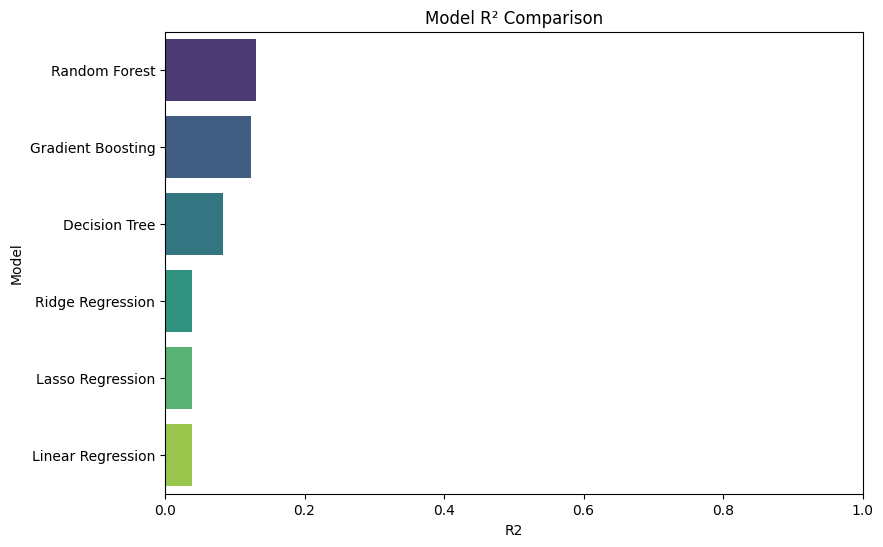

In [15]:
# %% [code]
# 15) Visualize model comparison
plt.figure(figsize=(9,6))
sns.barplot(x='R2', y='Model', data=results_df, palette='viridis')
plt.title("Model R² Comparison")
plt.xlim(0, 1)
plt.show()


In [16]:
# %% [code]
# 17) Select best model and save it (and the scaler + columns)
best_row = results_df.iloc[0]
best_model_name = best_row['Model']
best_model = models[best_model_name]
print("Best model:", best_model_name, "R2:", best_row['R2'])

# Save artifacts
import os
OUTPUT_DIR = "/mnt/data/models_usedcars"
os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(best_model, os.path.join(OUTPUT_DIR, "best_model.pkl"))
joblib.dump(scaler, os.path.join(OUTPUT_DIR, "scaler.pkl"))
# Save columns order for later transform
X_columns = X_dummies.columns.tolist()
pd.Series(X_columns).to_csv(os.path.join(OUTPUT_DIR, "feature_columns.csv"), index=False)
print("Saved model, scaler, and feature columns to", OUTPUT_DIR)


Best model: Random Forest R2: 0.13028427998737901
Saved model, scaler, and feature columns to /mnt/data/models_usedcars


In [17]:
# %% [code]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)


In [18]:
# %% [code]
# Load dataset
path = r"D:\virtual environment\used_cars.csv"  # adjust path if needed
df = pd.read_csv(path)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()


Shape: (4009, 12)

Columns: ['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price']


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [19]:
# %% [code]
# Clean price
df['price_clean'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

# Clean mileage
df['milage_clean'] = df['milage'].str.replace('mi.', '', regex=False).str.replace(',', '', regex=False)
df['milage_clean'] = pd.to_numeric(df['milage_clean'], errors='coerce')

# Drop rows with missing key info
df.dropna(subset=['price_clean', 'milage_clean', 'model_year'], inplace=True)

# Compute car age
CURRENT_YEAR = 2025
df['car_age'] = CURRENT_YEAR - df['model_year']

# Parse engine liters
import re
def extract_engine_liters(x):
    if pd.isna(x): return np.nan
    m = re.search(r'(\d+\.\d+|\d+)\s*[lL]', str(x))
    if m: return float(m.group(1))
    return np.nan

df['engine_liters'] = df['engine'].apply(extract_engine_liters)
df['engine_liters'].fillna(df['engine_liters'].median(), inplace=True)

# Select key features
df = df[(df['price_clean'] > 1000) & (df['price_clean'] < 200000)]
df = df[(df['milage_clean'] > 0) & (df['milage_clean'] < 300000)]

df.head()


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,price_clean,milage_clean,car_age,engine_liters
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300",10300.0,51000,12,3.7
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005",38005.0,34742,4,3.8
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598",54598.0,22372,3,3.5
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500",15500.0,88900,10,3.5
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999",34999.0,9835,4,2.0


In [20]:
# %% [code]
# Features for regression
features = ['car_age', 'milage_clean', 'engine_liters']
target = 'price_clean'

X = df[features]
y = df[target]

# Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numeric data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


In [21]:
# %% [code]
# Simple Linear Regression: using only mileage
X_train_slr = X_train_scaled[:, 1].reshape(-1, 1)  # milage_clean
X_val_slr = X_val_scaled[:, 1].reshape(-1, 1)

slr = LinearRegression()
slr.fit(X_train_slr, y_train)
y_pred_slr = slr.predict(X_val_slr)

# Metrics
mse_slr = mean_squared_error(y_val, y_pred_slr)
rmse_slr = np.sqrt(mse_slr)
r2_slr = r2_score(y_val, y_pred_slr)

print(f"Simple Linear Regression:\nMSE={mse_slr:.2f}, RMSE={rmse_slr:.2f}, R²={r2_slr:.4f}")


Simple Linear Regression:
MSE=589996202.88, RMSE=24289.84, R²=0.3592


In [22]:
# %% [code]
mlr = LinearRegression()
mlr.fit(X_train_scaled, y_train)
y_pred_mlr = mlr.predict(X_val_scaled)

mse_mlr = mean_squared_error(y_val, y_pred_mlr)
rmse_mlr = np.sqrt(mse_mlr)
r2_mlr = r2_score(y_val, y_pred_mlr)

print(f"Multiple Linear Regression:\nMSE={mse_mlr:.2f}, RMSE={rmse_mlr:.2f}, R²={r2_mlr:.4f}")


Multiple Linear Regression:
MSE=484253640.82, RMSE=22005.76, R²=0.4741


In [23]:
# %% [code]
poly = PolynomialFeatures(degree=5)
X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)

pr = LinearRegression()
pr.fit(X_train_poly, y_train)
y_pred_pr = pr.predict(X_val_poly)

mse_pr = mean_squared_error(y_val, y_pred_pr)
rmse_pr = np.sqrt(mse_pr)
r2_pr = r2_score(y_val, y_pred_pr)

print(f"Polynomial Regression (degree=2):\nMSE={mse_pr:.2f}, RMSE={rmse_pr:.2f}, R²={r2_pr:.4f}")


Polynomial Regression (degree=2):
MSE=373679613.06, RMSE=19330.79, R²=0.5942


In [24]:
# %% [code]
print("\n" + "="*65)
print(f"{'Model':<35}{'MSE':<12}{'RMSE':<12}{'R²':<12}")
print("="*65)
print(f"{'Simple Linear Regression':<35}{mse_slr:<12.2f}{rmse_slr:<12.2f}{r2_slr:<12.4f}")
print(f"{'Multiple Linear Regression':<35}{mse_mlr:<12.2f}{rmse_mlr:<12.2f}{r2_mlr:<12.4f}")
print(f"{'Polynomial Regression (deg=2)':<35}{mse_pr:<12.2f}{rmse_pr:<12.2f}{r2_pr:<12.4f}")

best_model = max([
    ('SLR', r2_slr),
    ('MLR', r2_mlr),
    ('PR', r2_pr)
], key=lambda x: x[1])
print(f"\n🏆 Best Model: {best_model[0]} with R² = {best_model[1]:.4f}")



Model                              MSE         RMSE        R²          
Simple Linear Regression           589996202.8824289.84    0.3592      
Multiple Linear Regression         484253640.8222005.76    0.4741      
Polynomial Regression (deg=2)      373679613.0619330.79    0.5942      

🏆 Best Model: PR with R² = 0.5942


In [26]:
# %% [code]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings, re
warnings.filterwarnings("ignore")


In [27]:
# %% [code]
path = r"D:\virtual environment\used_cars.csv"  # update if needed
df = pd.read_csv(path)

print("Original shape:", df.shape)
df.head()


Original shape: (4009, 12)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [28]:
# %% [code]
# Clean price column
df['price_clean'] = df['price'].replace('[\$,]', '', regex=True).astype(float)

# Clean mileage
df['milage_clean'] = df['milage'].str.replace('mi.', '', regex=False).str.replace(',', '', regex=False)
df['milage_clean'] = pd.to_numeric(df['milage_clean'], errors='coerce')

# Compute car age
CURRENT_YEAR = 2025
df['car_age'] = CURRENT_YEAR - df['model_year']

# Parse engine liters
def extract_engine_liters(x):
    if pd.isna(x): return np.nan
    m = re.search(r'(\d+\.\d+|\d+)\s*[lL]', str(x))
    return float(m.group(1)) if m else np.nan

df['engine_liters'] = df['engine'].apply(extract_engine_liters)
df['engine_liters'].fillna(df['engine_liters'].median(), inplace=True)


In [29]:
# %% [code]
# 1️⃣ Log-transform target (price)
df = df[(df['price_clean'] > 1000) & (df['price_clean'] < 200000)]
df['log_price'] = np.log1p(df['price_clean'])

# 2️⃣ Add brand & model encoding (reduce cardinality)
top_brands = df['brand'].value_counts().nlargest(10).index
df['brand_top'] = df['brand'].apply(lambda x: x if x in top_brands else 'Other')

top_models = df['model'].value_counts().nlargest(20).index
df['model_top'] = df['model'].apply(lambda x: x if x in top_models else 'Other')

# 3️⃣ Accident & title flags
df['had_accident'] = df['accident'].apply(lambda x: 0 if str(x).lower().startswith('none') else 1)
df['clean_title_flag'] = df['clean_title'].apply(lambda x: 1 if str(x).lower() == 'yes' else 0)

# 4️⃣ Transmission & fuel type (categorical dummies)
df['transmission'] = df['transmission'].fillna('Unknown')
df['fuel_type'] = df['fuel_type'].fillna('Unknown')

# 5️⃣ Interaction features
df['age_x_mileage'] = df['car_age'] * df['milage_clean']
df['age_x_engine'] = df['car_age'] * df['engine_liters']

# 6️⃣ Remove outliers
q1, q99 = df['price_clean'].quantile([0.01, 0.99])
df = df[(df['price_clean'] > q1) & (df['price_clean'] < q99)]

# 7️⃣ Scale numeric data after dummy encoding
df = pd.get_dummies(df, columns=['brand_top', 'model_top', 'transmission', 'fuel_type'], drop_first=True)

print("After feature engineering:", df.shape)


After feature engineering: (3848, 113)


In [30]:
# %% [code]
# Select features
features = [
    'car_age', 'milage_clean', 'engine_liters',
    'had_accident', 'clean_title_flag',
    'age_x_mileage', 'age_x_engine'
] + [col for col in df.columns if any(prefix in col for prefix in ['brand_top_', 'model_top_', 'transmission_', 'fuel_type_'])]

X = df[features]
y = df['log_price']  # log-transformed target

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


In [31]:
# %% [code]
# Simple Linear Regression (use only mileage)
X_train_slr = X_train_scaled[:, 1].reshape(-1, 1)
X_val_slr = X_val_scaled[:, 1].reshape(-1, 1)
slr = LinearRegression()
slr.fit(X_train_slr, y_train)
y_pred_slr = slr.predict(X_val_slr)

# Multiple Linear Regression (use all features)
mlr = LinearRegression()
mlr.fit(X_train_scaled, y_train)
y_pred_mlr = mlr.predict(X_val_scaled)

# Polynomial Regression (degree=2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)
pr = LinearRegression()
pr.fit(X_train_poly, y_train)
y_pred_pr = pr.predict(X_val_poly)


In [32]:
# %% [code]
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, r2

mse_slr, rmse_slr, r2_slr = evaluate(y_val, y_pred_slr)
mse_mlr, rmse_mlr, r2_mlr = evaluate(y_val, y_pred_mlr)
mse_pr, rmse_pr, r2_pr = evaluate(y_val, y_pred_pr)

print("\n" + "="*65)
print(f"{'Model':<35}{'MSE':<12}{'RMSE':<12}{'R²':<12}")
print("="*65)
print(f"{'Simple Linear Regression':<35}{mse_slr:<12.4f}{rmse_slr:<12.4f}{r2_slr:<12.4f}")
print(f"{'Multiple Linear Regression':<35}{mse_mlr:<12.4f}{rmse_mlr:<12.4f}{r2_mlr:<12.4f}")
print(f"{'Polynomial Regression (deg=2)':<35}{mse_pr:<12.4f}{rmse_pr:<12.4f}{r2_pr:<12.4f}")

best = max([('SLR', r2_slr), ('MLR', r2_mlr), ('PR', r2_pr)], key=lambda x: x[1])
print(f"\n🏆 Best Model: {best[0]} with R² = {best[1]:.4f}")



Model                              MSE         RMSE        R²          
Simple Linear Regression           0.2902      0.5387      0.4362      
Multiple Linear Regression         0.1323      0.3638      0.7429      
Polynomial Regression (deg=2)      0.2346      0.4843      0.5443      

🏆 Best Model: MLR with R² = 0.7429


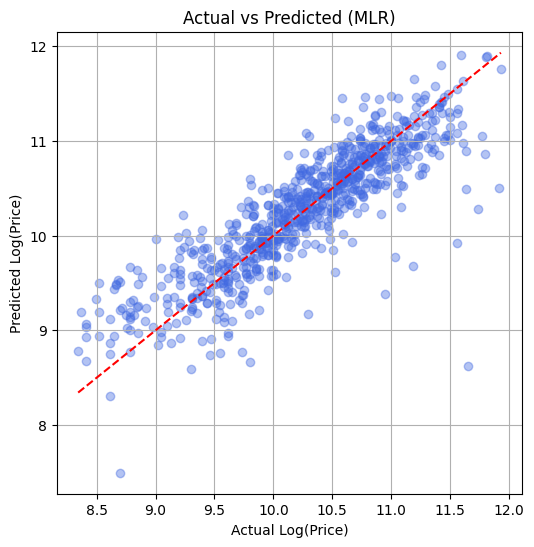

In [ ]:
# %% [code]
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred_mlr, alpha=0.4, color='royalblue')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("Actual Log(Price)")
plt.ylabel("Predicted Log(Price)")
plt.title("Actual vs Predicted (MLR)")
plt.grid(True)
plt.show()
